## 프롬프트

아래 설정을 따르도록 simpy를 이용해서 구현체 코드를 만들어줘

[기본 설정]
- 시간 단위: 1 = 1분
- 총 시뮬레이션 시간: 60,000분 (1,000시간)

[자원 (Resources)]
- 서버(직원): simpy.Resource, 총 1명

[프로세스 로직 (Process)]
1. 고객은 평균 5분 간격(지수분포)으로 지속해서 도착한다.
2. 도착한 고객은 '서버' 자원을 요청하고 대기한다.
3. 서버가 매칭되면 지수분포(평균 4분) 동안 서비스를 받는다.
4. 서비스가 끝나면 서버 자원을 반납하고 시스템을 이탈한다.

[요구사항 및 출력]
- 시뮬레이션 진행 상황을 시간별로 print하는 로그를 포함해줘.
- 시뮬레이션이 끝난 후 '고객들의 평균 대기 시간'과 '서버 가동률'을 계산해서 출력하는 로직을 구현해줘.
- 코드는 가독성이 좋게 주석을 상세히 달아주고, random seed를 설정해줘.
- 확률 시뮬레이션이니깐 n번 실행하고 lead time, utilization, throughput, wip을 smore plot으로 각각 보여줘

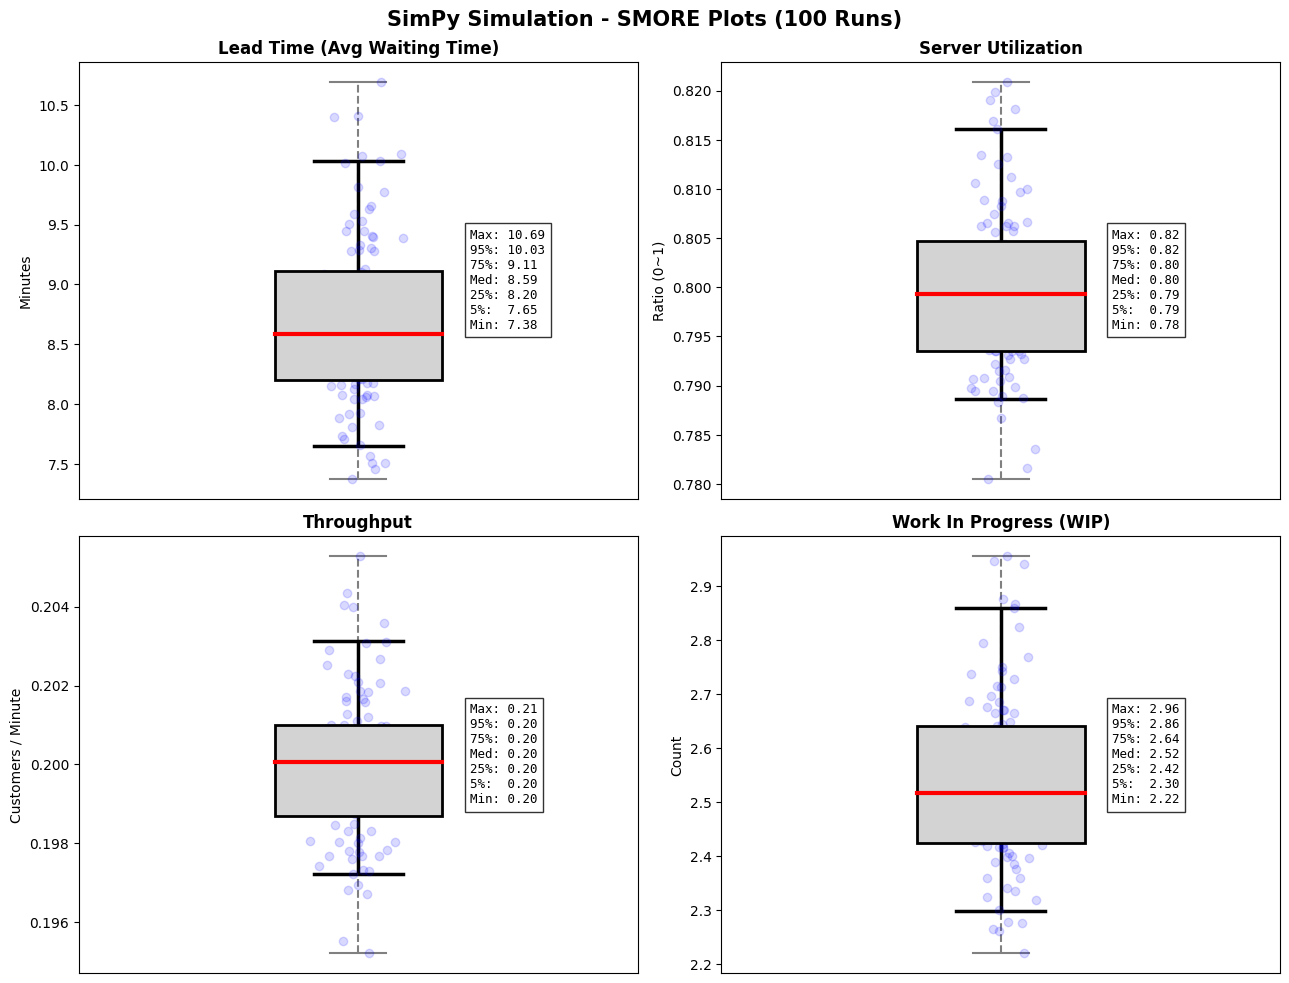

In [3]:
import random
import simpy
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. 글로벌 설정 (Configuration)
# ==========================================
RANDOM_SEED = 42
SIM_TIME = 60_000          # 총 시뮬레이션 시간: 60,000 (1000시간)
ARRIVAL_MEAN = 5.0      # 고객 도착 간격 평균: 5분 (지수분포)
SERVICE_MEAN = 4.0      # 서비스 시간 평균: 4분 (지수분포)
NUM_RUNS = 100          # 반복 실행 횟수 (n번)

all_avg_waiting_times = []
all_utilizations = []
all_throughputs = []
all_wips = []

# ==========================================
# 2. 시뮬레이션 모델 정의
# ==========================================
class BankSimulation:
    def __init__(self, env):
        self.env = env
        self.server = simpy.Resource(env, capacity=1)
        self.waiting_times = []
        self.total_service_time = 0
        self.completed_customers = 0
        self.wip_times = []
        self.wip_values = []
        self.current_wip = 0

    def record_wip(self):
        self.wip_times.append(self.env.now)
        self.wip_values.append(self.current_wip)

def customer_process(env, name, sim):
    arrival_time = env.now
    sim.current_wip += 1
    sim.record_wip()

    with sim.server.request() as request:
        yield request
        waiting_time = env.now - arrival_time
        sim.waiting_times.append(waiting_time)
        
        service_duration = random.uniform(2, 6)
        sim.total_service_time += service_duration
        yield env.timeout(service_duration)
        
        sim.completed_customers += 1

    sim.current_wip -= 1
    sim.record_wip()

def arrival_generator(env, sim):
    customer_id = 1
    while True:
        yield env.timeout(random.expovariate(1.0 / ARRIVAL_MEAN))
        env.process(customer_process(env, f"고객 {customer_id}", sim))
        customer_id += 1

# ==========================================
# 3. 시뮬레이션 반복 실행
# ==========================================
random.seed(RANDOM_SEED)

for run in range(NUM_RUNS):
    env = simpy.Environment()
    sim = BankSimulation(env)
    
    env.process(arrival_generator(env, sim))
    env.run(until=SIM_TIME)
    
    sim.wip_times.append(SIM_TIME)
    sim.wip_values.append(sim.current_wip)
    
    # 지표 수집
    avg_wait = np.mean(sim.waiting_times) if sim.waiting_times else 0
    all_avg_waiting_times.append(avg_wait)
    
    utilization = min(sim.total_service_time / SIM_TIME, 1.0)
    all_utilizations.append(utilization)
    
    throughput = sim.completed_customers / SIM_TIME
    all_throughputs.append(throughput)
    
    intervals = np.diff(sim.wip_times)
    time_weighted_wip = np.sum(intervals * np.array(sim.wip_values[:-1])) / SIM_TIME
    all_wips.append(time_weighted_wip)

# ==========================================
# 4. 커스텀 SMORE Plot 시각화 함수
# ==========================================
def draw_smore_plot(ax, data, title, unit):
    """지정된 축(ax)에 SMORE Plot 스타일의 그래프를 그립니다."""
    data = np.array(data)
    
    # SMORE 핵심 분위수 계산
    v_min = np.min(data)
    v_5 = np.percentile(data, 5)
    v_25 = np.percentile(data, 25)
    v_50 = np.median(data)
    v_75 = np.percentile(data, 75)
    v_95 = np.percentile(data, 95)
    v_max = np.max(data)
    
    x = 1 # 단일 변수 플롯이므로 x축 위치는 1로 고정
    
    # 1. 전체 범위 수직선 (Min ~ Max)
    ax.vlines(x, v_min, v_max, colors='gray', linestyles='dashed', linewidth=1.5)
    ax.plot([x-0.05, x+0.05], [v_min, v_min], color='gray', linewidth=1.5) # Min 가로 바
    ax.plot([x-0.05, x+0.05], [v_max, v_max], color='gray', linewidth=1.5) # Max 가로 바
    
    # 2. 95% 신뢰 구간 수직선 (5% ~ 95%)
    ax.vlines(x, v_5, v_95, colors='black', linestyles='solid', linewidth=2.5)
    ax.plot([x-0.08, x+0.08], [v_5, v_5], color='black', linewidth=2.5)   # 5% 가로 바
    ax.plot([x-0.08, x+0.08], [v_95, v_95], color='black', linewidth=2.5) # 95% 가로 바
    
    # 3. IQR 박스 격자 (25% ~ 75%)
    box_width = 0.3
    rect = plt.Rectangle((x - box_width/2, v_25), box_width, v_75 - v_25, 
                         facecolor='lightgray', edgecolor='black', linewidth=2, zorder=3)
    ax.add_patch(rect)
    
    # 4. 중위수선 (Median, 50%)
    ax.plot([x - box_width/2, x + box_width/2], [v_50, v_50], color='red', linewidth=3, zorder=4, label='Median')
    
    # 개별 데이터 포인트 분산 표시 (선택 사항, 경향성을 보기 위함)
    ax.scatter(np.random.normal(x, 0.03, size=len(data)), data, color='blue', alpha=0.15, zorder=2)
    
    # 스타일링 및 텍스트 정보 추가
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel(unit)
    ax.set_xlim(0.5, 1.5)
    ax.set_xticks([])
    
    # 분위수 텍스트 매핑
    stats_str = (f"Max: {v_max:.2f}\n"
                 f"95%: {v_95:.2f}\n"
                 f"75%: {v_75:.2f}\n"
                 f"Med: {v_50:.2f}\n"
                 f"25%: {v_25:.2f}\n"
                 f"5%:  {v_5:.2f}\n"
                 f"Min: {v_min:.2f}")
    ax.text(1.2, (v_max + v_min)/2, stats_str, bbox=dict(facecolor='white', alpha=0.8), 
            fontsize=9, family='monospace', verticalalignment='center')

# 차트 그리기
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
fig.suptitle(f"SimPy Simulation - SMORE Plots ({NUM_RUNS} Runs)", fontsize=15, fontweight='bold')

draw_smore_plot(axes[0, 0], all_avg_waiting_times, "Lead Time (Avg Waiting Time)", "Minutes")
draw_smore_plot(axes[0, 1], all_utilizations, "Server Utilization", "Ratio (0~1)")
draw_smore_plot(axes[1, 0], all_throughputs, "Throughput", "Customers / Minute")
draw_smore_plot(axes[1, 1], all_wips, "Work In Progress (WIP)", "Count")

plt.tight_layout()
plt.show()